<a href="https://colab.research.google.com/github/trewto/Machine-Learning-Models/blob/main/PredictExpenseType.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [26]:
file_path = '/content/drive/My Drive/Projects/ExpensetypePrediction/formltraining_expenselist.csv'
data = pd.read_csv(file_path)


In [ ]:
data.head()

In [ ]:
new_data = data[["description","Type"]]
new_data.head()


**Process with null data**

In [ ]:
# prompt: i want to see the number of missing value in description and Type and also want to see the unique Types

print(new_data.isnull().sum())
print(new_data['Type'].unique())


In [30]:
new_data = new_data.dropna()
new_data.isnull().sum()

,0
description,0
Type,0


In [ ]:
new_data.head()

In [44]:
# prompt: I want to see the numbers of each unique type

new_data['Type'].value_counts()


,count
Type,
Transportation,253
ColdDrink,207
Nasta,197
FastFood,164
Recharge,65
item,62
cha,56
Treat,55
Food,44


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert descriptions to TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000)  # Adjust max_features as needed
X = vectorizer.fit_transform(new_data['description']).toarray()

# Encode the target variable 'Type'
y = new_data['Type'].astype('category').cat.codes


In [ ]:
# prompt: i want to know which vector represent what

feature_names = vectorizer.get_feature_names_out()
print(feature_names)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
# prompt: i want to know the number where y_test  ="rent"

(y_test == 3).sum()


10

In [34]:
model = RandomForestClassifier(n_estimators=100, random_state=22)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=22)

In [35]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6886446886446886
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           2       0.33      0.50      0.40         2
           3       0.00      0.00      0.00        10
           4       0.97      0.84      0.90        43
           5       1.00      1.00      1.00         1
           6       0.68      0.75      0.71        28
           7       0.50      0.25      0.33         8
           8       0.50      0.17      0.25         6
           9       0.50      0.25      0.33         4
          10       0.00      0.00      0.00         2
          11       0.44      0.81      0.57        36
          14       0.82      0.69      0.75        13
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         1
          19       0.96      0.98      0.97        54
          20       0.54     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [36]:
import joblib
joblib.dump(model, '/content/drive/My Drive/Projects/ExpensetypePrediction/expense_type_model.pkl')


['/content/drive/My Drive/Projects/ExpensetypePrediction/expense_type_model.pkl']

In [37]:
# Example description to predict
new_description = ["rikshaw"]

# Transform the description using the same TF-IDF vectorizer
new_description_transformed = vectorizer.transform(new_description).toarray()

# Predict the type using the trained model
predicted_type_code = model.predict(new_description_transformed)

# Convert the predicted type code back to the original label
predicted_type = new_data['Type'].astype('category').cat.categories[predicted_type_code][0]

print(f"The predicted type for 'rikshaw' is: {predicted_type}")


The predicted type for 'rikshaw' is: Transportation


In [ ]:
# Predict the types for the test data
y_pred = model.predict(X_test)

# Convert the codes back to the original labels
category_mapping = dict(enumerate(new_data['Type'].astype('category').cat.categories))
actual_types = pd.Series(y_test).map(category_mapping).tolist()
predicted_types = pd.Series(y_pred).map(category_mapping).tolist()

# Since y_test is a numpy array, we need to get the correct descriptions from X_test
# Assuming X_test is derived from vectorized data, we need to trace back to the original descriptions
# Here we assume that X_test comes from a subset of data, so we'll use the original indices from the split

# Get the original descriptions using the same indices used for X_test
original_descriptions = data.iloc[y_test.index]['description'].values

# Create a DataFrame to hold descriptions, actual types, and predicted types
results_df = pd.DataFrame({
    'Description': original_descriptions,
    'Actual Type': actual_types,
    'Predicted Type': predicted_types
})

# Display the first few rows of the results
print(results_df.head(2))


In [46]:
# Check the distribution of types in the training set
train_type_distribution = pd.Series(y_train).map(category_mapping).value_counts()
print("Training set distribution:\n", train_type_distribution)

# Check the distribution of types in the test set
test_type_distribution = pd.Series(y_test).map(category_mapping).value_counts()
print("Test set distribution:\n", test_type_distribution)


Training set distribution:
 Transportation    199
ColdDrink         164
Nasta             161
FastFood          136
Recharge           52
item               50
cha                43
Treat              42
Food               36
Cha                30
food               28
ITEM               20
Water              20
Breakfast          17
Medicine           12
Stationary         12
treat               7
BUET_FEE            7
Shared_Rental       7
print               6
gift                6
Rent                5
Photocopy           5
Print               4
ma                  4
nasta               4
Selun               3
tour                3
dad                 2
Dhar                2
dhar                1
Book                1
Metro_Recharge      1
selun               1
book                1
Name: count, dtype: int64
Test set distribution:
 Transportation    54
ColdDrink         43
Nasta             36
FastFood          28
Recharge          13
Treat             13
cha               13
item 

**Plot confusion Matrix and Accuracy**

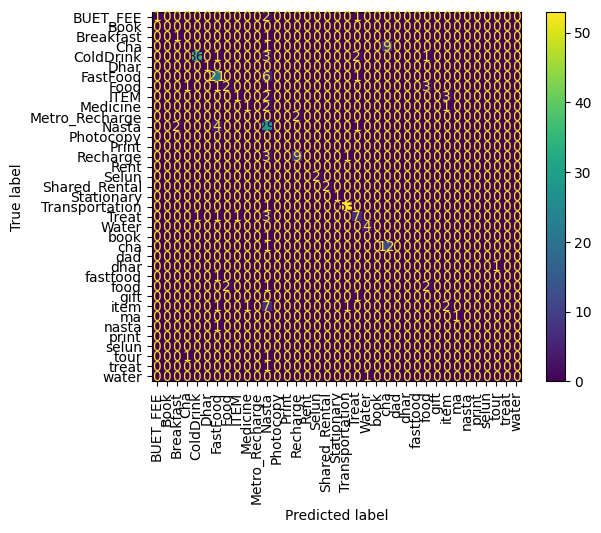

In [50]:
# prompt: please generate me a confusion matrix with type name

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(actual_types, predicted_types, labels=list(category_mapping.values()))

# Create the ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(category_mapping.values()))

# Plot the confusion matrix
disp.plot(xticks_rotation='vertical')
plt.show()


In [51]:
# prompt: print the accuracy rate

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.6886446886446886


**Predict Single Description**

In [61]:
# prompt: predict the type for a description "riksshaw fare"

# Example description to predict
new_description = ["juice"]

# Transform the description using the same TF-IDF vectorizer
new_description_transformed = vectorizer.transform(new_description).toarray()

# Predict the type using the trained model
predicted_type_code = model.predict(new_description_transformed)

# Convert the predicted type code back to the original label
predicted_type = new_data['Type'].astype('category').cat.categories[predicted_type_code][0]

print(f"The predicted type for is: {predicted_type}")



The predicted type for is: ColdDrink


**Print Multiple Data**

In [66]:
# Example descriptions
new_descriptions = ["juice", "rikshaw", "FEE"]

# Transform the descriptions using the same TF-IDF vectorizer
new_descriptions_transformed = vectorizer.transform(new_descriptions).toarray()

# Predict the types using the trained model
predicted_type_codes = model.predict(new_descriptions_transformed)

# Convert the predicted type codes back to the original labels
class_labels = new_data['Type'].astype('category').cat.categories
predicted_types = [class_labels[code] for code in predicted_type_codes]

# Display predictions
for description, predicted_type in zip(new_descriptions, predicted_types):
    print(f"The predicted type for '{description}' is: {predicted_type}")

The predicted type for 'juice' is: ColdDrink
The predicted type for 'rikshaw' is: Transportation
The predicted type for 'FEE' is: BUET_FEE
